# Mock Data Generation — Faker-Based Templates

This notebook accompanies the IEEE IRI 2026 paper *"A Privacy-Preserving Framework
Using Remote Data Science for Inter-Institutional Student Retention Prediction"*
([repo](https://github.com/jtfields/NAIRR240195-Privacy-Preserving-Machine-Learning)).

## Purpose

Generates mock institutional data using the **Faker** library, implementing the
**Data-Type-Aware Templates** method (Method 3) from Section III.C.1 of the paper.
Unlike SDV-based methods that learn statistical distributions, this approach
generates records that are structurally valid (correct types, valid ranges, valid
category labels) but have no statistical relationship to the underlying data.
This provides the strongest privacy protection of the three synthetic-data methods
evaluated.

## Output

A `synthetic_df` DataFrame containing Faker-generated records that match the
Faketucky column structure. In the production RDS workflow, mock data of this
type is hosted on the low-side server so external researchers can prototype model
code without ever seeing real data.

## Dataset

Uses the **Faketucky** synthetic college-going dataset from OpenSDP as the source
for column structure, valid ranges, and categorical labels. The Faker library then
fabricates new records that respect those constraints.

## Pipeline

1. Load Faketucky data
2. Identify binary columns (for special handling)
3. Filter to year-1 college attendees
4. Clean and impute missing values
5. Generate synthetic records using Faker, respecting observed ranges and categories
6. Verify the synthetic dataset preserves valid structure

## Requirements

- Python 3.10+
- `pandas`, `numpy`, `scikit-learn`, `faker`
- The Faketucky `.dta` file uploaded via `files.upload()

## 1. Installing Dependencies

To ensure all necessary libraries are available for data processing, the Faker package is installed .



*  The Faker library is used to generate synthetic or dummy data, such as names, addresses, emails, and other structured data.
*   It is helpful for testing, simulating real-world scenarios, or handling missing data in datasets.



In [24]:
!pip install faker


## 2. Importing Required Libraries

The following libraries are imported to facilitate data processing and analysis:

*   pandas: Used for data manipulation and analysis, providing functionalities to load, clean, and transform structured data efficiently.
*   numpy: Supports numerical operations and array-based computations, enhancing performance in data processing.

*  Faker: Generates synthetic (fake) data, such as names, addresses, emails, and more. This is useful for testing and handling missing values.






In [25]:
import pandas as pd
import numpy as np
from faker import Faker

## 3. Loading the Dataset

The dataset used in this analysis is Faketucky, which was downloaded from GitHub. The following steps were taken to make it accessible in Google Colab:


1.   The Faketucky dataset (faketucky.dta) was downloaded from GitHub.
2.   The dataset was then uploaded to Google Colab using the Colab file upload feature.

1. The uploaded dataset was read into a Pandas DataFrame using the Stata file format (.dta)









In [26]:
# Load packages and import Faketucky dataset
from google.colab import files
files.upload()

df = pd.read_stata("faketucky.dta")
df

Saving faketucky.dta to faketucky (1).dta


,sid,sid_type,first_coop_code,first_dist_code,first_hs_code,first_dist_name,first_hs_name,first_hs_alt,first_hs_urbanicity,chrt_ninth,...,ihe_retention_lt_4_yr_part_time,ihe_federal_loan_rate,ihe_share_25_older,ihe_med_debt_completers_all,ihe_med_debt_completers_pmts,ihe_ihe_repay_3_yr_all,ihe_rate_4_yr,ihe_rate_lt_4_yr,ihe_med_earn_10_yrs_after,ihe_pct_earn_gt_25k_6_yrs_after
0,10,Fake record,GRREC,103,1110,Jackson,Jackson,0,Rural: Distant,2010,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1622,Fake record,GRREC,103,1110,Jackson,Jackson,0,Rural: Distant,2009,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1877,Fake record,GRREC,103,1110,Jackson,Jackson,0,Rural: Distant,2009,...,0.4522,0.2661,0.3929,9740.0,108.133967,0.556974,NaN,0.398137,25000.0,0.44169
3,1941,Fake record,GRREC,103,1110,Jackson,Jackson,0,Rural: Distant,2009,...,0.4522,0.2661,0.3929,9740.0,108.133967,0.556974,NaN,0.398137,25000.0,0.44169
4,2405,Fake record,GRREC,103,1110,Jackson,Jackson,0,Rural: Distant,2010,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111986,94764,Fake record,Jeffco,613,9144,Lookout Point,Lookout Point,1,Town: Distant,2009,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
111987,97538,Fake record,Jeffco,613,9144,Lookout Point,Lookout Point,1,Town: Distant,2009,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
111988,101342,Fake record,Jeffco,613,9144,Lookout Point,Lookout Point,1,Town: Distant,2009,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
111989,104903,Fake record,Jeffco,613,9144,Lookout Point,Lookout Point,1,Town: Distant,2009,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
binary_columns = [col for col in df.columns if df[col].dropna().nunique() == 2 and set(df[col].dropna().unique()).issubset({0, 1})]
print("Binary Columns:", binary_columns)



Binary Columns: ['first_hs_alt', 'male', 'frpl_ever_in_hs', 'sped_ever_in_hs', 'lep_ever_in_hs', 'gifted_ever_in_hs', 'ever_alt_sch_in_hs', 'collegeready_ever_in_hs', 'careerready_ever_in_hs', 'ap_ever_take_class', 'transferout', 'dropout', 'still_enrolled', 'ontime_grad', 'hs_diploma', 'enroll_yr1_any', 'enroll_yr1_2yr', 'enroll_yr1_4yr', 'enroll_yr2_any']


In [28]:
for col in binary_columns:
    print(f"Column: {col}, Data Type: {df[col].dtype}, Unique Values: {df[col].unique()}")


Column: first_hs_alt, Data Type: int8, Unique Values: [0 1]
Column: male, Data Type: float64, Unique Values: [ 0.  1. nan]
Column: frpl_ever_in_hs, Data Type: float64, Unique Values: [ 1.  0. nan]
Column: sped_ever_in_hs, Data Type: int8, Unique Values: [0 1]
Column: lep_ever_in_hs, Data Type: int8, Unique Values: [0 1]
Column: gifted_ever_in_hs, Data Type: int8, Unique Values: [0 1]
Column: ever_alt_sch_in_hs, Data Type: int8, Unique Values: [0 1]
Column: collegeready_ever_in_hs, Data Type: int8, Unique Values: [0 1]
Column: careerready_ever_in_hs, Data Type: int8, Unique Values: [1 0]
Column: ap_ever_take_class, Data Type: int8, Unique Values: [0 1]
Column: transferout, Data Type: int8, Unique Values: [0 1]
Column: dropout, Data Type: int8, Unique Values: [0 1]
Column: still_enrolled, Data Type: int8, Unique Values: [0 1]
Column: ontime_grad, Data Type: int8, Unique Values: [1 0]
Column: hs_diploma, Data Type: int8, Unique Values: [1 0]
Column: enroll_yr1_any, Data Type: float64, Uni

### 4. Filtering Data

A subset of the dataset is created where students enrolled in the first year:

In [29]:
subset_data = df[(df['enroll_yr1_any'] == 1)]

In [30]:
print(subset_data.shape)

(44442, 68)


In [31]:
ct = pd.crosstab(subset_data['enroll_yr2_any'],columns='count')
ct

col_0,count
enroll_yr2_any,
0.0,27753
1.0,16689


### 5. Handling Missing Values

1. We calculated the percentage of missing values for each
column using .isnull().sum() / len(subset_data) * 100. This gave us a sense of how much data was missing in each column.

2. **Dropping Columns with Excessive Missing Data:** Explicitly, we dropped columns with more than 80% missing data. These columns were removed because they were considered too incomplete to provide meaningful insights or predictive power.

3.   **Imputation of Missing Values:**

*  **Numerical Data:** For numerical columns with missing
values, we decided to use imputation based on the distribution of the data:

    *  Columns with a high skew  (either positive or negative) were imputed using the median value, as this is more robust to outliers.
    *  Columns with a normal distribution were imputed using the mean value, assuming that the distribution of the data was not highly skewed.
*   **Categorical Data:** For categorical columns, we used the mode (most frequent value) to fill in missing data, as it reflects the most common category within that feature.


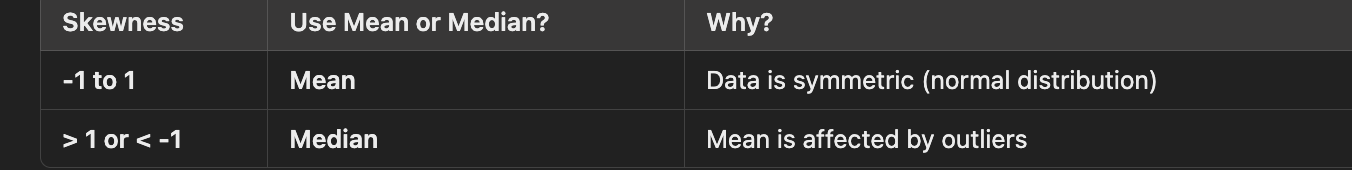




4.   **Applying KNN Imputation:**

The KNN imputation algorithm fills missing values by using the k nearest neighbors (rows) based on other features. The Income value for the row with the missing data is computed as the average of the Income values of the nearest rows (neighbors) with non-missing values.

We applied KNN imputation for numerical columns to fill in missing values based on the values of other similar data points.The KNNImputer() was used with 5 nearest neighbors (n_neighbors=5) to impute missing values in a more sophisticated manner, leveraging relationships between rows of the dataset.

5.  **Saving the Cleaned Data:**

   After processing the missing values, the cleaned dataset was saved to a new file named "faketucky_cleaned_optimized.dta" using .to_stata().

**Why we have chosen this approach over first one for handling missing values?**



1.  Unlike the first code, which focuses on dropping columns with more than 10% missing data, this approach uses imputation to fill in missing values. This is beneficial because dropping columns can lead to data loss, especially when columns with only a small percentage of missing values are still important for analysis.
2.   This approach takes into account the skewness of numerical data. If a column is highly skewed, it uses the median to impute the missing values. The median is less affected by extreme outliers and better represents the central tendency in skewed distributions.

 For normally distributed data, mean imputation is used, which is appropriate when the data follows a bell-shaped curve.

3.   The KNN imputation technique is introduced to handle missing values in a more sophisticated manner. By using the KNN algorithm, we impute missing values based on the similarity between rows, which can lead to more accurate imputation compared to simple mean/median imputation. This is particularly important when the dataset has complex relationships between features.

4.  This approach allows us to **preserve the integrity of the dataset**. Rather than removing rows or columns that might contain valuable information, imputation helps to fill in missing values and ensure that the dataset remains as complete as possible.









In [33]:
import pandas as pd
from sklearn.impute import KNNImputer

# Step 1: Subset the data where enroll_yr1_any == 1
df_subset = df[df["enroll_yr1_any"] == 1].copy()

# Step 2: Identify missing values percentage per column
missing_percentages = df_subset.isnull().mean() * 100

# Step 3: Explicitly drop **all** columns with more than 80% missing values
columns_to_drop = [
    "ihe_avg_net_price_priv",
    "ihe_retention_lt_4_yr_full_time",
    "ihe_retention_lt_4_yr_part_time",
    "ihe_rate_lt_4_yr"
]
df_cleaned = df_subset.drop(columns=columns_to_drop, errors='ignore')

# Step 4: Separate numerical and categorical variables
num_cols = df_cleaned.select_dtypes(include=['float64', 'int64']).columns
cat_cols = df_cleaned.select_dtypes(include=['object', 'category']).columns
binary_cols = [col for col in num_cols if df_cleaned[col].nunique() == 2]

# Step 5: Impute missing values
for col in num_cols:
    if df_cleaned[col].isnull().sum() > 0:
        if df_cleaned[col].skew() > 1 or df_cleaned[col].skew() < -1:
            df_cleaned[col].fillna(df_cleaned[col].median(), inplace=True)  # Median for skewed
        else:
            df_cleaned[col].fillna(df_cleaned[col].mean(), inplace=True)  # Mean for normal distribution

for col in cat_cols:
    if df_cleaned[col].isnull().sum() > 0:
        df_cleaned[col].fillna(df_cleaned[col].mode()[0], inplace=True)  # Mode for categorical

# Step 6: Apply KNN Imputation for numerical columns only
knn_imputer = KNNImputer(n_neighbors=5)
df_cleaned[num_cols] = knn_imputer.fit_transform(df_cleaned[num_cols])

# Step 7: Save the cleaned dataset
cleaned_file_path = "faketucky_cleaned_optimized.dta"
df_cleaned.to_stata(cleaned_file_path)

print(f"✅ Optimized cleaned dataset saved to {cleaned_file_path}")


/tmp/ipykernel_1587/3688152992.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cleaned[col].fillna(df_cleaned[col].mean(), inplace=True)  # Mean for normal distribution
/tmp/ipykernel_1587/3688152992.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doi

✅ Optimized cleaned dataset saved to faketucky_cleaned_optimized.dta


In [34]:
df_cleaned

,sid,sid_type,first_coop_code,first_dist_code,first_hs_code,first_dist_name,first_hs_name,first_hs_alt,first_hs_urbanicity,chrt_ninth,...,ihe_retention_4_yr_full_time,ihe_retention_4_yr_part_time,ihe_federal_loan_rate,ihe_share_25_older,ihe_med_debt_completers_all,ihe_med_debt_completers_pmts,ihe_ihe_repay_3_yr_all,ihe_rate_4_yr,ihe_med_earn_10_yrs_after,ihe_pct_earn_gt_25k_6_yrs_after
2,1877,Fake record,GRREC,103,1110,Jackson,Jackson,0,Rural: Distant,2009,...,0.7178,0.4386,0.266100,0.392900,9740.000000,108.133967,0.556974,0.471098,25000.000000,0.441690
3,1941,Fake record,GRREC,103,1110,Jackson,Jackson,0,Rural: Distant,2009,...,0.7178,0.4386,0.266100,0.392900,9740.000000,108.133967,0.556974,0.471098,25000.000000,0.441690
7,3044,Fake record,GRREC,103,1110,Jackson,Jackson,0,Rural: Distant,2010,...,0.7178,0.4615,0.541300,0.181800,24431.000000,271.234184,0.663946,0.432884,34600.000000,0.541185
8,3268,Fake record,GRREC,103,1110,Jackson,Jackson,0,Rural: Distant,2010,...,0.6884,0.4444,0.472500,0.168600,19500.000000,216.489975,0.662626,0.441241,32100.000000,0.475793
9,3442,Fake record,GRREC,103,1110,Jackson,Jackson,0,Rural: Distant,2009,...,0.7178,0.4386,0.473807,0.274274,19454.074945,215.980113,0.645742,0.471098,32195.886273,0.531849
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111948,111486,Fake record,Jeffco,607,9902,Snowy Hill,Corcoran,0,City: Large,2010,...,0.7788,0.4386,0.432300,0.206500,21500.000000,238.694075,0.778179,0.527847,37700.000000,0.641691
111964,11078,Fake record,Jeffco,613,9144,Lookout Point,Lookout Point,1,Town: Distant,2010,...,0.7788,0.4386,0.432300,0.206500,21500.000000,238.694075,0.778179,0.527847,37700.000000,0.641691
111966,22881,Fake record,Jeffco,613,9144,Lookout Point,Lookout Point,1,Town: Distant,2009,...,0.7788,0.4386,0.432300,0.206500,21500.000000,238.694075,0.778179,0.527847,37700.000000,0.641691
111984,85748,Fake record,Jeffco,613,9144,Lookout Point,Lookout Point,1,Town: Distant,2010,...,0.5167,0.5000,0.679000,0.201300,34942.000000,387.927831,0.428335,0.159809,26600.000000,0.420263


To display the total number of missing values (nulls) in the df_cleaned DataFrame after cleaning.

In [35]:
print(df_cleaned.isnull().sum().sum())

0


The Faker library in Python is used to generate fake data for testing, development, or demonstration purposes.

In [36]:
# Initialize Faker
fake = Faker()


## Generating Mock data

This code is designed to generate a synthetic dataset that mirrors the statistical properties and structure of an original dataset (df) for testing, modeling, or analysis.

  1. The first step is to understand the structure of the original dataset, specifically the types of variables it contains:
   
   **Categorical columns**: These columns hold non-numeric data, like categories or labels (e.g., "yes/no", "male/female").
   
   **Numeric columns**: These columns are further divided into integers and floating-point numbers (e.g., prices, measurements). Identifying these column types ensures that synthetic data is generated correctly for each type.


2.  **Defining Value Ranges and Categories**


*  **Range of numeric values:** For numeric columns, the minimum and maximum values are calculated. This helps ensure that the synthetic dataset remains within plausible boundaries.
*   **Unique categories for categorical columns:** For categorical columns, the unique values present in the original data are extracted, so that the synthetic dataset reflects the same variety of categories.


3.  **Generating the Synthetic Data**
Using Faker, the code generates synthetic rows that adhere to the following rules:


*  Integers are generated within the observed range (min to max) for each integer column, mimicking real-world values.
*  Floats are generated within their respective ranges, ensuring that continuous numeric data (like prices or scores) remains realistic.
*   Categorical data is drawn randomly from the unique categories in the original dataset, ensuring the synthetic data retains the same structure.


4. **Generating Multiple Rows**

 To mimic the original dataset's size, the code generates num_rows synthetic rows. This helps simulate a full dataset while maintaining the statistical characteristics of the original data.
5.   **Compiling the Data**

 After generating each synthetic row, the data is collected into a list and then transformed into a pandas DataFrame (synthetic_df). This makes it easier to use the generated data for analysis, model training, or testing.



























In [37]:
import random
# Identify categorical and numeric columns
categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()
integer_columns = df.select_dtypes(include=['int8', 'int16', 'int32', 'int64']).columns.tolist()
float_columns = df.select_dtypes(include=['float64']).columns.tolist()

# Get value ranges for numeric columns
integer_ranges = {col: (df[col].min(), df[col].max()) for col in integer_columns if df[col].notna().any()}
float_ranges = {col: (df[col].min(), df[col].max()) for col in float_columns if df[col].notna().any()}

# Get unique values for categorical columns
categorical_values = {col: df[col].dropna().unique().tolist() for col in categorical_columns}

# Generate synthetic data
num_rows = 44442
synthetic_data = []

for _ in range(num_rows):
    row = {}

   # Generate integer values within observed ranges
    for col, (min_val, max_val) in integer_ranges.items():
        row[col] = fake.random_int(min=min_val, max=max_val)

    # Ensure binary columns stay as 0 or 1 and include both 0 and 1
    for col in binary_columns:
        if random.random() < 0.5:
            row[col] = 0
        else:
            row[col] = 1

    # Generate float values within observed ranges
    for col, (min_val, max_val) in float_ranges.items():
        row[col] = round(fake.pyfloat(min_value=min_val, max_value=max_val, right_digits=4), 4)

    # Randomly select from categorical values
    for col, values in categorical_values.items():
        row[col] = fake.random_element(values) if values else None

    synthetic_data.append(row)

# Create a new DataFrame
synthetic_df = pd.DataFrame(synthetic_data)

# Convert binary columns back to integers to ensure they remain 0 or 1
for col in binary_columns:
    synthetic_df[col] = synthetic_df[col].astype(int)


# Verify unique values of binary columns to ensure correctness
for col in binary_columns:
    print(f"{col} unique values: {synthetic_df[col].unique()}")

first_hs_alt unique values: [0 1]
male unique values: [1 0]
frpl_ever_in_hs unique values: [0 1]
sped_ever_in_hs unique values: [0 1]
lep_ever_in_hs unique values: [1 0]
gifted_ever_in_hs unique values: [0 1]
ever_alt_sch_in_hs unique values: [0 1]
collegeready_ever_in_hs unique values: [0 1]
careerready_ever_in_hs unique values: [0 1]
ap_ever_take_class unique values: [1 0]
transferout unique values: [0 1]
dropout unique values: [0 1]
still_enrolled unique values: [0 1]
ontime_grad unique values: [1 0]
hs_diploma unique values: [1 0]
enroll_yr1_any unique values: [1 0]
enroll_yr1_2yr unique values: [1 0]
enroll_yr1_4yr unique values: [0 1]
enroll_yr2_any unique values: [1 0]


In [38]:
synthetic_df

,sid,first_dist_code,first_hs_code,first_hs_alt,chrt_ninth,male,frpl_ever_in_hs,sped_ever_in_hs,lep_ever_in_hs,gifted_ever_in_hs,...,sid_type,first_coop_code,first_dist_name,first_hs_name,first_hs_urbanicity,race_ethnicity,ihe_name_yr1,ihe_barrons_rank_2013,ihe_degrees_awarded_predominant,ihe_degrees_awarded_highest
0,69985,111,3327,0,2009,1,0,0,1,0,...,Fake record,SESC,Quigley,Greenfield,Town: Distant,Asian/Pacific Islander,South Hadley College,,Predominantly associate's-degree granting,Associate degree
1,19979,314,9214,1,2010,1,0,1,1,1,...,Fake record,KVEC,Homer,Nyquist,Rural: Fringe,Hispanic,Wright Brothers College,Less Competitive,Predominantly associate's-degree granting,Graduate degree
2,81413,335,8858,0,2009,1,1,0,0,1,...,Fake record,NKCES,Mount Lyon,Glenbrook,Town: Remote,Multiple/Native American,Duckley College,Competitive,Predominantly certificate-degree granting,Graduate degree
3,74426,533,5400,1,2010,0,1,1,0,1,...,Fake record,Jeffco,Hercules,Carmen,Suburb: Mid-size,Multiple/Native American,Coolidge University,Highly Competitive,Predominantly associate's-degree granting,Bachelor's degree
4,1958,588,9476,0,2010,0,1,0,0,0,...,Fake record,GRREC,Common Way,Suarez,City: Small,White,Dover College,Most Competitive,Predominantly associate's-degree granting,Graduate degree
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44437,110956,375,4966,0,2009,0,0,0,1,0,...,Fake record,KVEC,Midlands,Onassis,Suburb: Mid-size,Asian/Pacific Islander,OUT OF STATE OTHER,Most Competitive,Predominantly associate's-degree granting,Bachelor's degree
44438,69783,156,7119,0,2009,0,1,1,1,1,...,Fake record,SESC,Garner,Prentice,City: Large,Hispanic,Duckley College,Very Competitive,Predominantly certificate-degree granting,Associate degree
44439,27799,541,3651,1,2009,1,1,1,0,1,...,Fake record,KEDC,Beckham,Winchester,Suburb: Large,African-American,,Most Competitive,Predominantly bachelor's-degree granting,Graduate degree
44440,6676,498,2055,1,2009,1,0,0,0,1,...,Fake record,OVEC,Orozco,Spring Port,Town: Remote,Asian/Pacific Islander,Hippocrates College,,Predominantly certificate-degree granting,Bachelor's degree


**Saving the Synthetic Dataset**

The generated synthetic data can be saved as a CSV file This allows the dataset to be shared, stored, or analyzed without compromising privacy or security concerns.



1. **Importing the Required Library:**

  The line from google.colab import files imports the files
  module from the google.colab library, which provides methods for file management, including downloading files in a Google Colab environment.

2. **Saving the DataFrame as a CSV File:**

 synthetic_df.to_csv("mock_faketucky.csv", index=False) saves the synthetic dataset (synthetic_df) as a CSV file.
The file is named **mock_faketucky.csv**


 3. **Initiating the Download:**

 files.download("mock_faketucky.csv") triggers the download of the saved CSV file. Once the command is executed, a download link is generated within the Colab environment, allowing the user to save the file directly to their local machine.







In [39]:
unique_values =synthetic_df['enroll_yr1_2yr'].unique()
print(unique_values)

[1 0]
